# Recurrent neural networks

-----

RNN은 미래를 예측하기 위해 고안된 신경망이다.

시계열 데이터를 분석해서 예측하기 위한 것으로 임의 길이를 가진 시퀀스를 다룰 수 있으며, 자연어 처리에도 유용하다.

RNN은 일반적인 feed-forward 신경망의 다음의 단점을 해결하기 위해 도입되었다.

* 순차적인 데이터를 처리할 수 없음  
* 현재 입력만이 고려됨  
* 이전의 입력을 기억할 수 없음

## 순환 뉴런

지금까지는 활성화 신호가 입력층에서 출력층 한 방향으로만 흐르는 피드포워드 신경망에 초점을 맞추었지만

순환 신경망은 뒤쪽으로 순환하는 연결도 있다는 점이 다르다.

입력을 받아 출력을 만들고, 출력을 다음 층 뿐만아니라, 자신에게도 출력을 되보내는 순환 뉴런을 생각해 보자.

각 타임 스텝 $t$ (프레임)마다 이 순환 뉴런은 $x_t$와 이전 타임 스텝의 출력인 $y_{t-1}$을 입력으로 받는다.

- 이전 타임 스텝을 입력으로 받지 않는다면, Timedistributed dense와 동일

첫 번째 타임스텝에서는 이전 출력이 없으므로 0으로 설정.

각 순환 뉴런은 두 벌의 가중치를 지닌다.

하나는 입력 $x_t$를 위한 것이고, 다른 하나는 이전 타임 스텝의 출력 $y_{t-1}$를 위한 것이다.

아래 그림의 왼쪽은 이러한 순환 뉴런을 나타낸 것이다.

오른쪽은 시간을 축으로 하여, 시간에 따라 네트워크를 펼친 그림이다. 

* 동일한 뉴런을 복사하여 그림으로 표현한 것

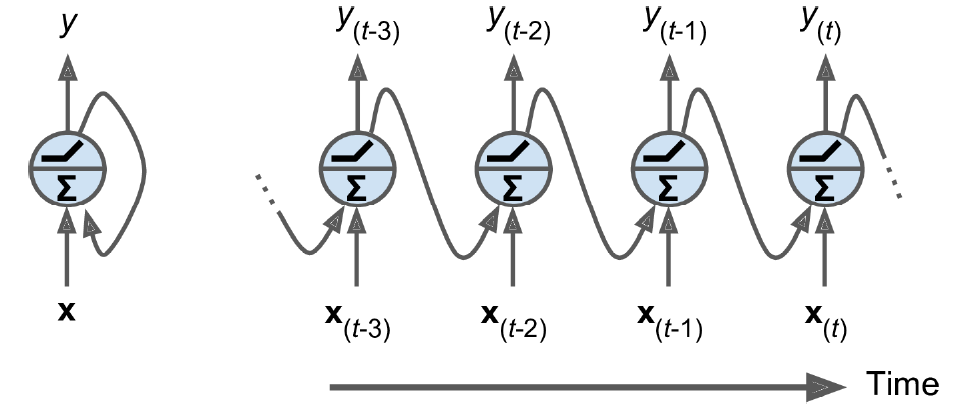

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

가장 단순한 Simple RNN은 [`keras.layers.SimpleRNN`](https://keras.io/api/layers/recurrent_layers/simple_rnn/)을 이용하여 다음과 같이 생성할 수 있다.

- 기본 활성화 함수는 `activation="tanh"`

- $\tanh$ 함수는 $(-1, 1)$의 값을 가지며, 이를 통해 순환 구조에서 값이 발산하지 않도록 함

In [2]:
simple_rnn_model = keras.models.Sequential([
    keras.Input(shape=(None, 1)),
    keras.layers.SimpleRNN(units = 1)])

이 모형은 일변량 시계열을 입력으로 받는 유닛 하나와 layer 하나로 구성된 RNN이다.

* ```input_shape = (None, 1)```에서 ```1```이 일변량 시계열을 입력 받음을 의미

In [3]:
simple_rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

유닛 하나에 $x_t$와 $y_{t-1}$를 위한 두 개의 parameter들과 편향을 위한 parameter까지 총 3개의 parameter가 있다.

간단한 RNN layer에서 출력되는 값을 살펴보자.

아래의 코드에서는 길이가 3인 sequence ```x```를 input으로 사용하였다.

```x```의 ```shape```은 ```(1,3,1)```로서 가장 처음의 1은 sequence sample의 개수, 두 번째 3은 sequence의 길이, 마지막 1은 1변량 sequence임을 의미한다.

In [4]:
# input
x = np.array([1.0, 2.0, 3.0]).reshape(1,-1,1)
x.shape

(1, 3, 1)

In [5]:
RNN_layer1 = keras.models.Sequential([keras.Input(shape=(None, 1)), keras.layers.SimpleRNN(units = 1)])
RNN_layer1(x)

<tf.Tensor: shape=(1, 1), dtype=float32, numpy=array([[-0.5068691]], dtype=float32)>

```return_sequences = True```로 하면 모든 스텝별로 계산된 sequence가 출력된다.

현재 입력 sequence의 길이가 3이므로, 3개의 결과가 출력된다.

```return_sequences = True```의 활용 방안에 대해서는 추후에 살펴본다.

In [6]:
keras.models.Sequential([keras.Input(shape=(None, 1)), keras.layers.SimpleRNN(units = 1, return_sequences = True)])(x)

<tf.Tensor: shape=(1, 3, 1), dtype=float32, numpy=
array([[[0.79251623],
        [0.99452347],
        [0.99957573]]], dtype=float32)>

다른 shape의 input들에 대해서도 연습해 보자.

In [7]:
# two-dimensional input
x2 = np.array([[1.0, 2.0, 3.0, 4.0],
               [4.0, 3.0, 2.0, 1.0]]).reshape(1,-1,2)
x2.shape

(1, 4, 2)

In [8]:
keras.models.Sequential([keras.Input(shape=(None, 2)), keras.layers.SimpleRNN(units = 1, return_sequences = True)])(x2)

<tf.Tensor: shape=(1, 4, 1), dtype=float32, numpy=
array([[[-0.9356922 ],
        [-0.99986094],
        [-0.99982464],
        [-0.98717386]]], dtype=float32)>

모형을 만들어 파라미터 개수를 확인해 보자.

- 아래 코드에서 `input_shape = (4,2)`는 길이 4의 2차원 데이터가 입력됨을 의미한다. `(time step, dimension)`
  - 임의의 길이 시퀀스의 `input_shape`을 의미하도록 `(None, 2)`로 설정할 수도 있음 
- 2차원 input x를 담당하는 parameter 2개, y를 담당하는 파라미터 1개, bias 1개의 parameter가 존재함

In [9]:
simple_rnn_model2 = keras.models.Sequential([
    keras.Input(shape=(4, 2)),
    keras.layers.SimpleRNN(units = 1, return_sequences = True)])
simple_rnn_model2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_4 (SimpleRNN)        │ (None, 4, 1)           │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (16.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
# two one-dimensional input
x3 = np.array([[1.0, 2.0, 3.0, 4.0],
               [4.0, 3.0, 2.0, 1.0]]).reshape(2,-1,1)
x3.shape

(2, 4, 1)

In [11]:
keras.models.Sequential([keras.Input(shape=(None, 1)), keras.layers.SimpleRNN(units = 1, return_sequences = True)])(x3)

<tf.Tensor: shape=(2, 4, 1), dtype=float32, numpy=
array([[[0.53847176],
        [0.5820318 ],
        [0.8408215 ],
        [0.91657627]],

       [[0.98393196],
        [0.67619526],
        [0.48370254],
        [0.11774953]]], dtype=float32)>

### 여러 유닛을 가지는 RNN layer

만약 layer 내의 unit의 수를 늘리고자 한다면 다음과 같이 가능하다.  

이렇게 하면 타임 스텝 $t$마다 모든 뉴런은 이전 타임 스텝의 출력을 벡터로 받게 된다.  

Input이 층 내의 모든 유닛들에 연결되고, 유닛을 통과한 출력들이 다시 모든 유닛들에 순환 연결된다.  

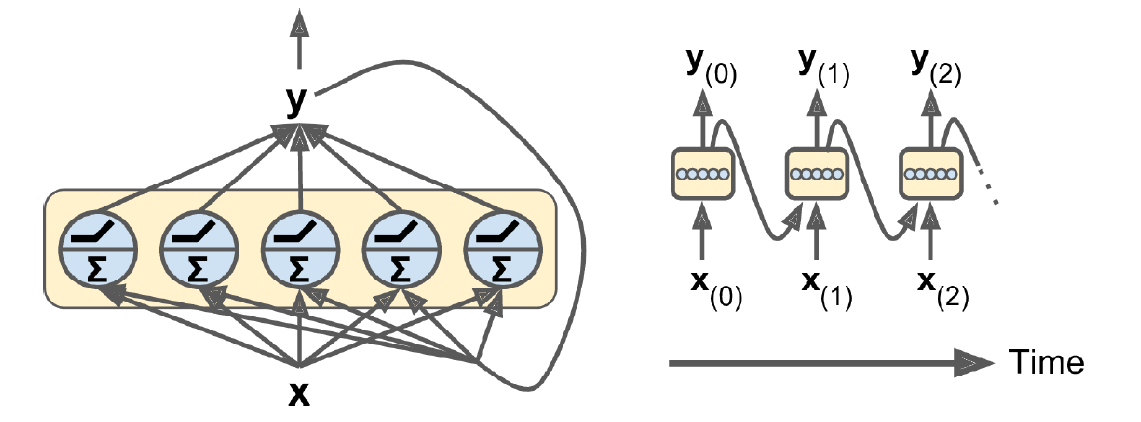

수식으로 표현하면 다음과 같다.

$$
\mathbf{y}_t = \phi(\mathbf{W}_h \mathbf{y}_{t-1} + \mathbf{W}_x \mathbf{x}_t + \mathbf{b}_h)
$$

뉴런의 개수를 `n_h`라 하고, `x`의 dimension을 `dim`이라 할 때

* $\mathbf{W}_x$의 shape :  `(n_h, n_x)`
* $\mathbf{W}_h$의 shape :  `(n_h, n_h)` 
* $\mathbf{b}_h$의 shape : `(n_h, )`
* $\phi(\cdot)$: 활성화 함수

In [12]:
simple_rnn_model2 = keras.models.Sequential([
    keras.Input(shape=[None, 1]),
    keras.layers.SimpleRNN(units = 5)])

In [13]:
simple_rnn_model2.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_6 (SimpleRNN)        │ (None, 5)              │            35 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35 (140.00 B)

 Trainable params: 35 (140.00 B)

 Non-trainable params: 0 (0.00 B)

위 모델에서는 각 유닛 당 총 7개의 paramter가 존재한다.   
* 각 타임 스텝에서 하나의 입력 $x_t$ 에 대한 가중치 parameter 
* 5개의 이전 스텝 출력 $y_{t-1}$에 대한 가중치 parameter
* 그리고 편향 parameter 

이러한 유닛이 총 5개 있으므로 $5 \times 7 = 35$개의 parameter가 존재한다.  

Unit이 여러 개인 RNN layer의 출력 결과를 살펴보자.  
길이가 3인 sequence ```x```를 input으로 사용하여 본다.

In [14]:
x

array([[[1.],
        [2.],
        [3.]]])

In [15]:
keras.models.Sequential([keras.Input(shape=(None, 1)), keras.layers.SimpleRNN(units = 5)])(x)

<tf.Tensor: shape=(1, 5), dtype=float32, numpy=
array([[-0.5733742 ,  0.7649432 , -0.95082426, -0.9871776 ,  0.9850379 ]],
      dtype=float32)>

모든 스텝마다의 계산 결과를 보고 싶다면 ```return_sequences = True```를 사용한다.

In [16]:
keras.models.Sequential([keras.Input(shape=(None, 1)), keras.layers.SimpleRNN(units = 5, return_sequences = True)])(x)

<tf.Tensor: shape=(1, 3, 5), dtype=float32, numpy=
array([[[-0.17204107,  0.11437266,  0.36616385,  0.5493927 ,
         -0.6941973 ],
        [-0.527669  , -0.3555888 ,  0.47414201,  0.507256  ,
         -0.91681784],
        [-0.81579185, -0.27910796,  0.52178085,  0.85561407,
         -0.9666112 ]]], dtype=float32)>

만약 입력 $x$가 다변량이라면 그만큼 parameter 수가 늘어날 것이다.

In [17]:
simple_rnn_model3 = keras.models.Sequential([
    keras.Input(shape=[None, 3]),
    keras.layers.SimpleRNN(units = 5)])

In [18]:
simple_rnn_model3.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_9 (SimpleRNN)        │ (None, 5)              │            45 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45 (180.00 B)

 Trainable params: 45 (180.00 B)

 Non-trainable params: 0 (0.00 B)

위 모델에서는 각 유닛 당 총 9개의 paramter가 존재한다.  
* 각 타임 스텝에서 3개의 입력 $x_t$에 대한 가중치 parameter
* 5개의 이전 스텝 출력 $y_{t-1}$에 대한 가중치 parameter
* 편향 parameter

이러한 유닛이 총 5개 있으므로 $5 \times 9 = 45$개의 parameter가 존재한다.  

입력이 2-dimension인 데이터에 대해 RNN layer의 출력 결과를 테스트 해 보자.

In [19]:
x2 = np.array([1.0, 4.0, 
               2.0, 5.0, 
               3.0, 6.0,
               4.0, 7.0]).reshape(1, -1, 2)
x2

array([[[1., 4.],
        [2., 5.],
        [3., 6.],
        [4., 7.]]])

In [20]:
keras.models.Sequential([keras.Input(shape=(None, 2)), keras.layers.SimpleRNN(units = 3)])(x2)

<tf.Tensor: shape=(1, 3), dtype=float32, numpy=array([[-0.99997056,  1.        ,  0.9994401 ]], dtype=float32)>

In [21]:
keras.models.Sequential([keras.Input(shape=(None, 2)), keras.layers.SimpleRNN(units = 3, return_sequences = True)])(x2)

<tf.Tensor: shape=(1, 4, 3), dtype=float32, numpy=
array([[[ 0.9983284 ,  0.97481596, -0.99764204],
        [ 0.99998677,  0.9299132 , -0.9897474 ],
        [ 0.9999991 ,  0.9621756 , -0.99488264],
        [ 1.        ,  0.9790747 , -0.9974764 ]]], dtype=float32)>

### Deep RNN

RNN을 여러 층으로 쌓을 수 있다. 이를 심층 RNN이라 한다.

Keras로 쉽게 구현할 수 있다.  

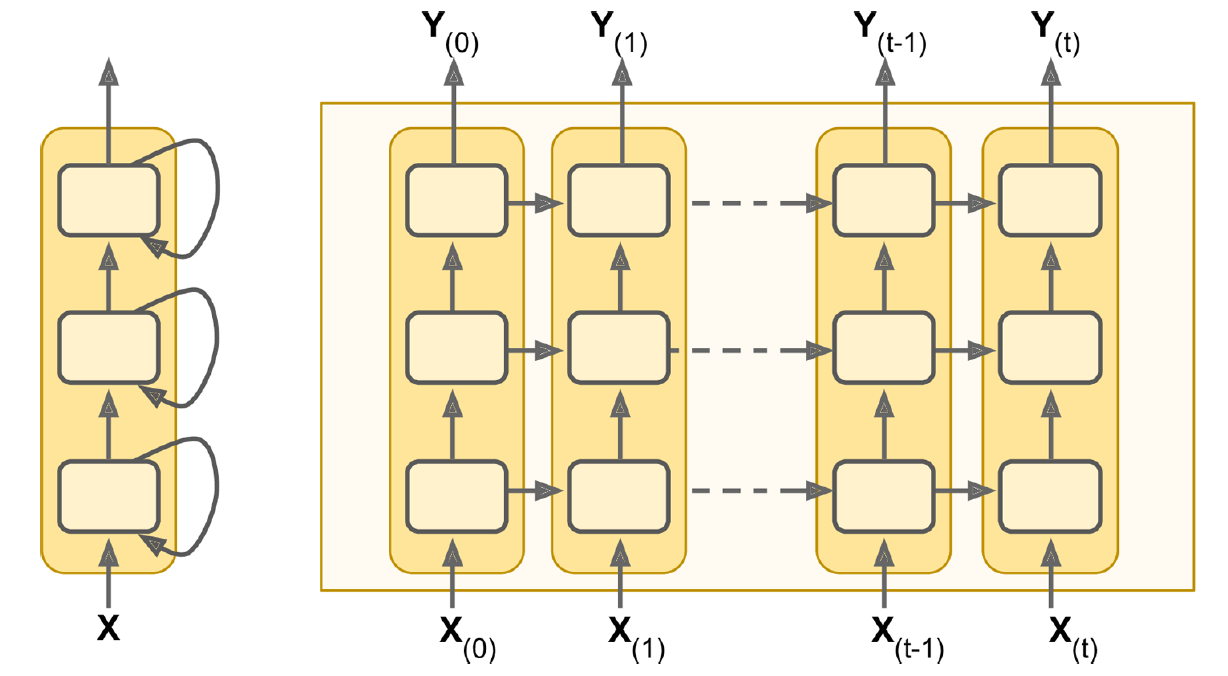

첫 번째 ```SimpleRNN```에서 두 번째 ```SimpleRNN```으로 전달할 때, 모든 time step에서의 출력을 전달하기 위해,```return_sequences=True```를 사용하였다.

이렇게 하면 step 별로 생성되는 sequence들을 전부 다음 layer로 전달하며 두번째 층 또한 일련의 시계열을 입력받는 셈이다.

In [22]:
## 예제 코드
model = keras.models.Sequential([
    keras.Input(shape=[None, 2]),
    keras.layers.SimpleRNN(30, return_sequences=True),
    keras.layers.SimpleRNN(15, return_sequences=True),
    keras.layers.SimpleRNN(1)
])

In [23]:
model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_12 (SimpleRNN)       │ (None, None, 30)       │           990 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_13 (SimpleRNN)       │ (None, None, 15)       │           690 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_14 (SimpleRNN)       │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,697 (6.63 KB)

 Trainable params: 1,697 (6.63 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# 첫번째 layer의 파라미터 수 
(2 + 30 + 1) * 30

990

In [25]:
# 두번째 layer의 파라미터 수 
(30 + 15 + 1) * 15

690

In [26]:
# 마지막 layer의 파라미터 수
15 + 1 + 1

17

위 예제에서는 마지막 층에 RNN을 사용하였으나, 마지막 층은 보통 Dense 층으로 하는 것이 더 유용하다고 알려져 있다.

이후의 예제에서 두번째 RNN layer의 `return_sequence`를 `False`로 취하고, 마지막을 Dense 층으로 바꾼 코드를 살펴볼 것이다.

## 시계열 예제
-------

시계열을 입력 받아 예측하는 RNN을 구현해 보기 위해, 먼저 임의의 시계열을 생성하는 함수를 만들어 보겠다.

아래 코드에서 ```...```는 ellipsis라고 불리우며, 여러 차원을 한꺼번에 선택할 때 사용한다.

```np.newaxis```는 차원을 증가시켜 준다.

In [27]:
def generate_time_series(batch_size, n_steps):
    freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
    time = np.linspace(0, 1, n_steps)
    series = 0.5 * np.sin((time - offsets1) * (freq1 * 10 + 10))  #   wave 1
    series += 0.2 * np.sin((time - offsets2) * (freq2 * 20 + 20)) # + wave 2
    series += 0.1 * (np.random.rand(batch_size, n_steps) - 0.5)   # + noise
    return series[..., np.newaxis].astype(np.float32)

In [28]:
generate_time_series(batch_size = 1, n_steps = 5)

array([[[-0.5786997 ],
        [ 0.12880546],
        [-0.5183852 ],
        [ 0.1453343 ],
        [-0.48768872]]], dtype=float32)

In [29]:
generate_time_series(2, 5).shape

(2, 5, 1)

### 마지막 값 예측하기

위 함수를 이용하여 50+1 step의 시계열을 생성한다.  

이중 처음 50개의 step의 값들을 이용하여 마지막 하나의 값을 예측하는 예제를 진행할 것이다.

위에서 생성되는 시계열은 램덤성이 포함되어 있기는 하지만, sin 곡선의 형태를 바탕으로하기 때문에 어느 정도 예측의 정확성을 높일 수 있다.

In [30]:
np.random.seed(42)

n_steps = 50
series = generate_time_series(batch_size = 10000, n_steps = n_steps + 1)
X_train, y_train = series[:7000, :n_steps], series[:7000, -1]
X_valid, y_valid = series[7000:9000, :n_steps], series[7000:9000, -1]
X_test, y_test = series[9000:, :n_steps], series[9000:, -1]

In [31]:
y_train

array([[-0.35489398],
       [ 0.11629631],
       [-0.35395944],
       ...,
       [ 0.04946356],
       [-0.26231018],
       [ 0.60062087]], shape=(7000, 1), dtype=float32)

In [32]:
X_train.shape, y_train.shape

((7000, 50, 1), (7000, 1))

랜덤하게 생성된 시계열을 그려 보자. 마지막 값은 X 기호로 표현하였다.

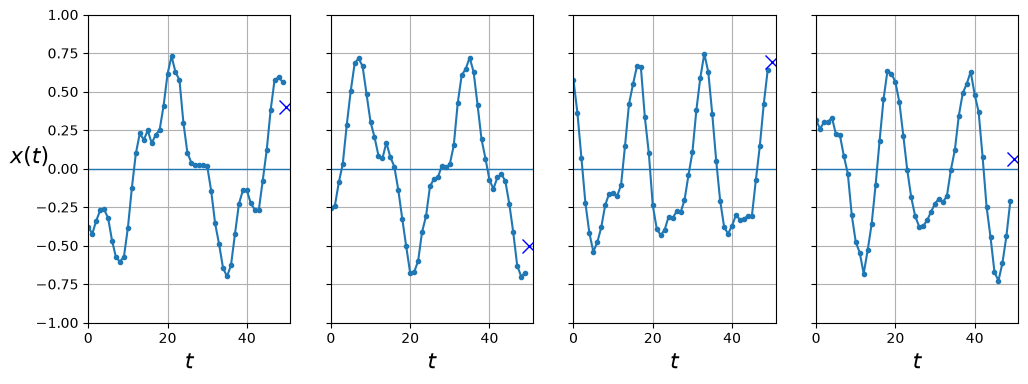

In [33]:
def plot_series(series, y=None, y_pred=None, x_label="$t$", y_label="$x(t)$"):
    plt.plot(series, ".-")
    if y is not None:
        plt.plot(n_steps, y, "bx", markersize=10)
    if y_pred is not None:
        plt.plot(n_steps, y_pred, "ro")
    plt.grid(True)
    if x_label:
        plt.xlabel(x_label, fontsize=16)
    if y_label:
        plt.ylabel(y_label, fontsize=16, rotation=0)
    plt.hlines(0, 0, 100, linewidth=1)
    plt.axis([0, n_steps + 1, -1, 1])

fig, axes = plt.subplots(nrows=1, ncols=4, sharey=True, figsize=(12, 4))
for col in range(4):
    plt.sca(axes[col])
    plot_series(X_valid[col, :, 0], y_valid[col, 0],
                y_label=("$x(t)$" if col==0 else None))
plt.show()

단순 예측 (naive forecasting), 다시 말해, 가장 나중에 관찰된 값을 다음 예측에 그대로 이용해 보자.

즉, $\hat t_{51} = t_{50}$를 이용한다.

이 방법으로 예측된 값과 [`keras.losses.mean_squared_error`](https://keras.io/api/losses/regression_losses/#meansquarederror-class)로 MSE를 측정했을 때, 비교적 괜찮은 정확도를 가지고 있는 것을 볼 수 있다.

In [34]:
y_pred = X_valid[:, -1]  #마지막 값
np.mean(keras.losses.MSE(y_valid, y_pred))

np.float32(0.020211367)

아래 그림에서 붉은 동그라미가 마지막 값을 이용한 단순 예측값이고, x로 표현된 좌표는 실제 값이다.

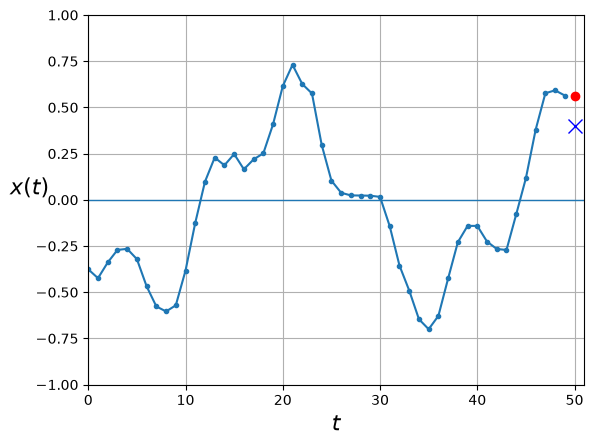

In [35]:
plot_series(X_valid[0, :, 0], y_valid[0, 0], y_pred[0, 0])
plt.show()

훈련 데이터 하나는 길이 50의 실현된 시계열이다. 

In [36]:
X_train[:1]

array([[[ 0.4596948 ],
        [ 0.31486678],
        [ 0.12497123],
        [-0.1039134 ],
        [-0.33817387],
        [-0.53167135],
        [-0.65472883],
        [-0.6680997 ],
        [-0.6068115 ],
        [-0.50168324],
        [-0.27951923],
        [-0.15070675],
        [ 0.01001816],
        [ 0.11860766],
        [ 0.09566415],
        [ 0.1479297 ],
        [ 0.16850619],
        [ 0.19524719],
        [ 0.22094081],
        [ 0.38448656],
        [ 0.4021102 ],
        [ 0.5566975 ],
        [ 0.55000687],
        [ 0.47437248],
        [ 0.29733396],
        [ 0.13306592],
        [-0.1292547 ],
        [-0.36367297],
        [-0.49515054],
        [-0.65279794],
        [-0.6665792 ],
        [-0.5604573 ],
        [-0.50344354],
        [-0.28775147],
        [-0.12684062],
        [-0.0095053 ],
        [ 0.12024356],
        [ 0.18013756],
        [ 0.1559989 ],
        [ 0.1756968 ],
        [ 0.217454  ],
        [ 0.30272725],
        [ 0.38143268],
        [ 0

#### keras.layers.SimpleRNN

앞에서 살펴본 것처럼 ```keras.layers.SimpleRNN```를 이용하여 간단한 RNN을 구현할 수 있다.  

1차원 시계열이므로, ```input_shape = [None, 1]```로 하여, 유닛 하나만 있는 RNN에 훈련 데이터 하나 ```X_train[:1]```를 적용해 계산해 보자.

* 임의의 길이의 시계열 input이 입력될 수 있으므로, `input_shape`의 첫번째 값은 ```None```을 이용하였음 

아래 코드에서는 가장 마지막 스텝의 값만 반환된다.

* ```srnn_layer(X_train[0])```로 하면 에러가 발생하니 주의, 즉, 데이터가 하나더라도 배치로 입력해야 함

In [37]:
srnn_layer = keras.models.Sequential([keras.Input(shape=(None, 1)), keras.layers.SimpleRNN(units = 1)])
srnn_layer(X_train[:1])

<tf.Tensor: shape=(1, 1), dtype=float32, numpy=array([[0.02929036]], dtype=float32)>

#### return_sequences=True

```return_sequences=True```로 하면 모든 time step에서의 출력 결과를 모두 반환하도록 할 수 있다.

이 예제에서는 50개의 step이 있으므로 50개의 값이 반환된다.

이렇게 sequence로 반환할 경우, 다음 RNN layer에서 입력으로 사용할 수 있다.

In [38]:
keras.models.Sequential([keras.Input(shape=(None, 1)), keras.layers.SimpleRNN(units = 1, return_sequences=True)])(X_train[:1])

<tf.Tensor: shape=(1, 50, 1), dtype=float32, numpy=
array([[[ 0.54822063],
        [-0.1257378 ],
        [ 0.28503746],
        [-0.4005013 ],
        [-0.05248779],
        [-0.5782104 ],
        [-0.29030785],
        [-0.5403979 ],
        [-0.26597008],
        [-0.38516814],
        [ 0.01070751],
        [-0.20945668],
        [ 0.21925905],
        [-0.06029212],
        [ 0.18624981],
        [ 0.01192485],
        [ 0.21061599],
        [ 0.05090446],
        [ 0.2402889 ],
        [ 0.26807782],
        [ 0.26419458],
        [ 0.4475159 ],
        [ 0.28149527],
        [ 0.33991966],
        [ 0.05833989],
        [ 0.11935136],
        [-0.28444198],
        [-0.200022  ],
        [-0.43277848],
        [-0.415092  ],
        [-0.4445572 ],
        [-0.2970345 ],
        [-0.3604541 ],
        [-0.02502926],
        [-0.14388826],
        [ 0.13040754],
        [ 0.0306681 ],
        [ 0.20759304],
        [ 0.00139215],
        [ 0.22980303],
        [ 0.06143355],
     

이 모형에서는 가장 마지막 스텝 직후의 시계열 값을 예측하는 것이 목표이다.

훈련을 위해 모형을 만들자.

#### 시퀀스-투-벡터 단층 RNN 모형 (Many-to-one 단층 RNN 모형)

입력 시퀀스를 네트워크에 주입하고, 마지막을 제외한 모은 출력은 최종 출력에서 생략됨.

- 입력은 시퀀스(여러 시점)이고 출력은 하나의 벡터(한 시점의 상태)

  - 하나의 시점이라는 뜻에서 벡터라고 표현하였지만, unit이 하나라 스칼라라고 표현 가능 

In [39]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.Input(shape=[None, 1]),
    keras.layers.SimpleRNN(units = 1)
])

가장 간단한 형태의 RNN에는 3개의 parameter가 있다. 
* 입력 $x_{(t)}$을 위한 것, 이전 타임 스텝의 출력 $y_{(t-1)}$을 위한 것, 편향 $b$에 해당하는 것

In [40]:
model.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_17 (SimpleRNN)       │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

#### Loss function

$y$가 양적 변수이기 때문에 loss function을 ```"mse"```로 하였다. 컴파일 후 훈련하여 보자.

In [41]:
optimizer = keras.optimizers.Adam(learning_rate=0.005)
model.compile(loss="mse", optimizer=optimizer)
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_valid, y_valid), verbose=2)

Epoch 1/20


219/219 - 4s - 17ms/step - loss: 0.3382 - val_loss: 0.1798


Epoch 2/20


219/219 - 2s - 7ms/step - loss: 0.1499 - val_loss: 0.1472


Epoch 3/20


...

219/219 - 1s - 7ms/step - loss: 0.0126 - val_loss: 0.0120


Epoch 19/20


219/219 - 1s - 7ms/step - loss: 0.0121 - val_loss: 0.0116


Epoch 20/20


219/219 - 1s - 7ms/step - loss: 0.0118 - val_loss: 0.0113


Validation set에 대한 MSE 측정 결과

In [42]:
model.evaluate(X_valid, y_valid)

 1/63 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0131

15/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0113 

38/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0112

58/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0113

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0113


0.011272314935922623

In [43]:
# Validation set에 대한 예측값
y_pred = model.predict(X_valid)
y_pred

 1/63 ━━━━━━━━━━━━━━━━━━━━ 9s 160ms/step

27/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  

55/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


array([[ 0.5133699 ],
       [-0.59515744],
       [ 0.6108924 ],
       ...,
       [-0.18866998],
       [-0.18975425],
       [ 0.48129943]], shape=(2000, 1), dtype=float32)

일부를 선택하여, 실제값과 예측값을 비교하는 그래프를 생성해 보자.  

실제 값은 X 모양으로, 예측값은 동그라미로 표현하였다.

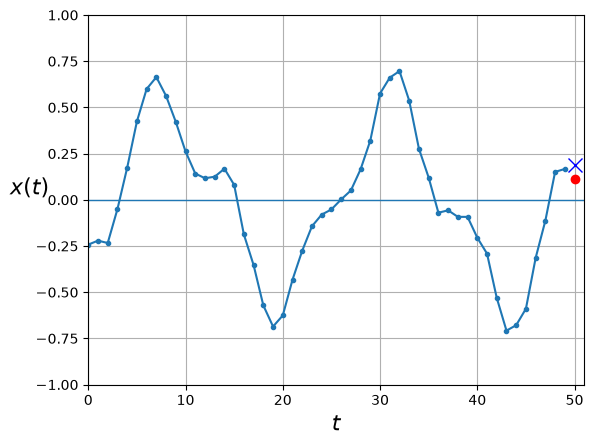

In [44]:
plot_series(X_valid[4, :, 0], y_valid[4, 0], y_pred[4, 0])
plt.show()

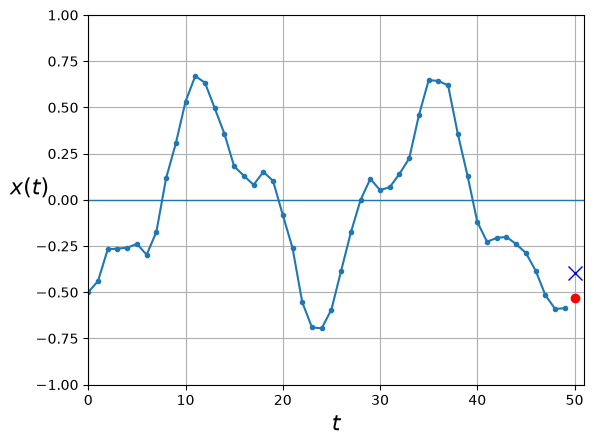

In [45]:
plot_series(X_valid[5, :, 0], y_valid[5, 0], y_pred[5, 0])
plt.show()

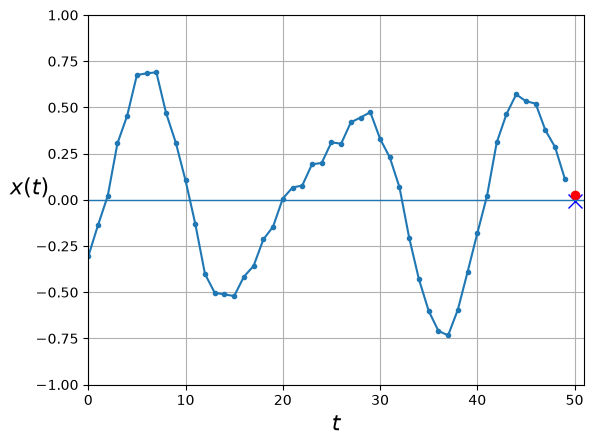

In [46]:
plot_series(X_valid[20, :, 0], y_valid[20, 0], y_pred[20, 0])
plt.show()

### 심층 RNN

#### 시퀀스-투-벡터 심층 RNN 모형 (Many-to-one 심층 RNN 모형)

위의 간단한 모형을 unit의 개수와 layer를 늘려 더 복잡한 모형으로 만들어 보자.

마지막 층은 Dense layer로 하였다. 이를 위해 두번째 `SimpleRNN`의 `return_sequence`는 `False`이다.

In [47]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.Input(shape=[None, 1]),
    keras.layers.SimpleRNN(units=20, return_sequences=True),
    keras.layers.SimpleRNN(units=20),
    keras.layers.Dense(1)
])

예를 들어, 이 모형의 첫번째 layer에 길이 50의 시계열 하나를 입력하면, 뉴런 20개가 각각 50 길이의 결과를 출력한다.

`return_sequence=True`이므로, 첫번째 layer의 출력값은 20차원의 time step 50의 시계열로 간주할 수 있다.

아래 `shape`은 곧 `(sample_size, time_step, dimension)`이다.

In [48]:
model.get_layer(index = 0)(X_train[:1]).shape

TensorShape([1, 50, 20])

In [49]:
model.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_18 (SimpleRNN)       │ (None, None, 20)       │           440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_19 (SimpleRNN)       │ (None, 20)             │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,281 (5.00 KB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 0 (0.00 B)

#### Parameter

앞에서 살펴본 것처럼 첫 번째 layer의 각 unit에는 총 22개의 parameter가 존재한다.  
* 각 unit에는 20개의 뉴런에서 출력되는 $y_{(t-1)}$
* 1개의 $x_{(t)}$
* 그리고 1개의 편향을 담당하는 parameter 

이러한 unit이 총 20개 존재하므로 첫 번째 layer의 총 paramter 수는 $22 \times 20 = 440$개이다.  

두 번째 layer에는 각 unit에는 총 41개의 parameter가 존재한다.  
* 해당 layer의 20개 unit에서 출력되는 $y_{(t-1)}$
* 이전 layer의 output에서 나오는 출력값 20개
* 그리고 1개의 편향까지 

이러한 unit이 총 20개 존재하므로 두 번째 layer의 총 paramter 수는 $41 \times 20 = 820$개이다.  

마지막 dense 층에는 20의 input과 하나의 bias를 처리하는 한 개의 unit만 있으므로 총 21개의 parameter가 있다.

In [50]:
model.compile(loss="mse", optimizer="adam")
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_valid, y_valid), verbose=2)

Epoch 1/20


219/219 - 3s - 16ms/step - loss: 0.0133 - val_loss: 0.0053


Epoch 2/20


219/219 - 3s - 12ms/step - loss: 0.0041 - val_loss: 0.0040


Epoch 3/20


...

219/219 - 1s - 6ms/step - loss: 0.0029 - val_loss: 0.0026


Epoch 19/20


219/219 - 3s - 11ms/step - loss: 0.0029 - val_loss: 0.0026


Epoch 20/20


219/219 - 3s - 12ms/step - loss: 0.0029 - val_loss: 0.0026


In [51]:
model.evaluate(X_valid, y_valid)

 1/63 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0014

14/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0023 

25/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0025

37/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0025

52/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0026

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0026


0.0025687727611511946

아래 그림에서 X 표시는 실제값, 붉은 원은 RNN을 이용한 예측값이다.

상당히 예측을 잘 하는 것을 볼 수 있다.

 1/63 ━━━━━━━━━━━━━━━━━━━━ 15s 258ms/step

11/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step   

23/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

35/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

45/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

55/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


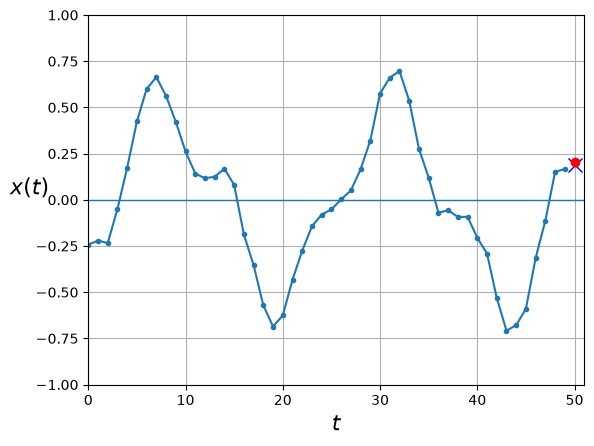

In [52]:
y_pred = model.predict(X_valid)
plot_series(X_valid[4, :, 0], y_valid[4, 0], y_pred[4, 0])
plt.show()

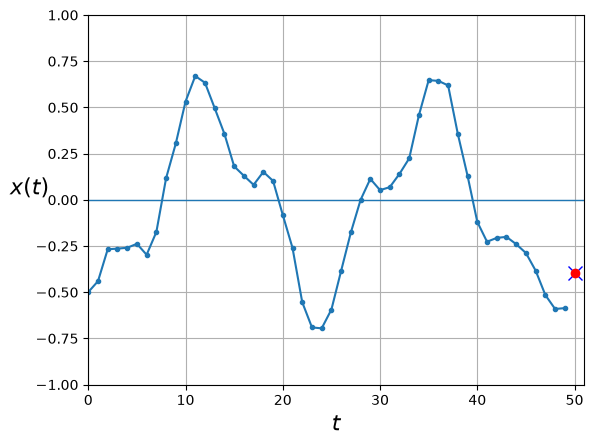

In [53]:
plot_series(X_valid[5, :, 0], y_valid[5, 0], y_pred[5, 0])
plt.show()

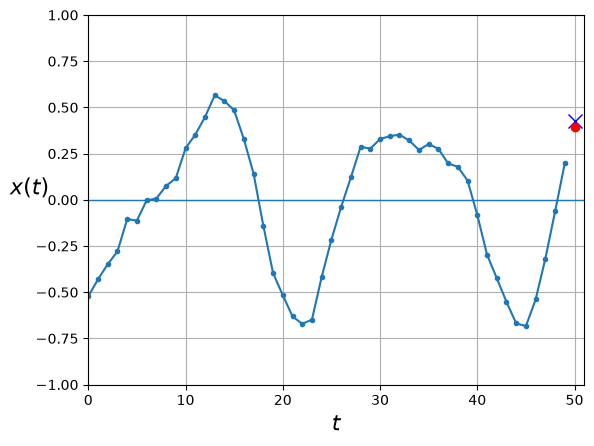

In [54]:
plot_series(X_valid[25, :, 0], y_valid[25, 0], y_pred[25, 0])
plt.show()

### 여러 스텝에 대한 예측

이전에는 한 스텝 미래에 대한 예측을 하였다면, 이제는 여러 스텝의 미래를 예측하는 훈련을 해 보자.

#### 출력이 1개인 시퀀스-투-벡터 모형의 반복 사용

이를 위한 첫번째 방법으로 위에서 작성한 Many-to-one 모델을 사용하여 다음 값을 예측한 다음 이 값을 입력으로 추가하여 다시 다음 값을 예측하는 행위를 반복하여 여러 스텝을 예측할 수 있다.

이 방법의 단점은 보다 먼 미래에 대한 예측일수록 오차가 누적될 수 있다.  

앞서 훈련한 모델을 그대로 이용하여 10개의 미래 step에 대해 예측을 진행해 보자.

예측된 값을 계속 연장하면서 다음 step을 예측하고 있다.

새로운 time series를 하나 생성하여 살펴 보겠다.

In [55]:
np.random.seed(43) # not 42, as it would give the first series in the train set

series = generate_time_series(1, n_steps + 10)  
X_new, Y_new = series[:, :n_steps], series[:, n_steps:]
X = X_new

In [56]:
X.shape

(1, 50, 1)

In [57]:
Y_new.shape

(1, 10, 1)

아래 코드에서 50개의 과거자료를 prediction에 사용한다는 의미로 ```X[:, step_ahead:]```를 사용하였다.

- 여기서 `step_ahead`는 for문을 돌면서 0이상 10미만의 정수가 대응됨

- ```X[:, step_ahead:]```의 길이는 항상 50이다.

한편, ```model.predict(X[:, step_ahead:])```의 ```shape```은 ```(1,1)```인데, ```X```와 concatenate하기 위해 ```shape```을 ```(1,1,1)```로 변환해 준다.


In [58]:
for step_ahead in range(10):
    
    y_pred_one = model.predict(X[:, step_ahead:])[:, np.newaxis, :]  # 새로운 차원을 추가하기 위해 np.newaxis 이용

    # 예측한 y값을 이전의 X들에 연결한다.
    X = np.concatenate([X, y_pred_one], axis=1)

Y_pred = X[:, n_steps:]  #50이후의 값들

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


In [59]:
# 10개의 미래 step에 대해 예측
Y_pred

array([[[ 0.5804914 ],
        [ 0.5972777 ],
        [ 0.5534171 ],
        [ 0.44954967],
        [ 0.27389508],
        [ 0.06239064],
        [-0.14947863],
        [-0.32324597],
        [-0.44597936],
        [-0.49650797]]], dtype=float32)

In [60]:
Y_pred.shape

(1, 10, 1)

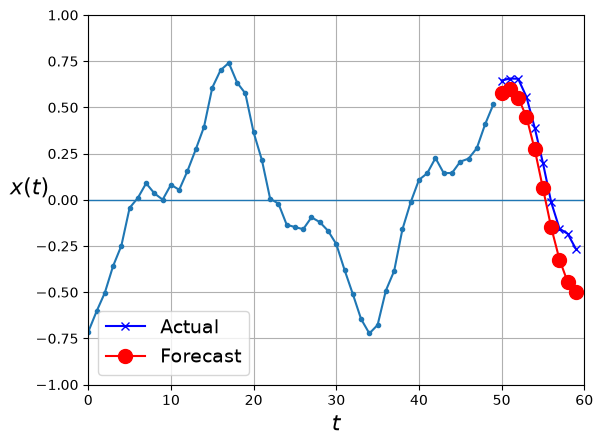

In [61]:
def plot_multiple_forecasts(X, Y, Y_pred):
    n_steps = X.shape[1]
    ahead = Y.shape[1]
    plot_series(X[0, :, 0])
    plt.plot(np.arange(n_steps, n_steps + ahead), Y[0, :, 0], "bx-", label="Actual")
    plt.plot(np.arange(n_steps, n_steps + ahead), Y_pred[0, :, 0], "ro-", label="Forecast", markersize=10)
    plt.axis([0, n_steps + ahead, -1, 1])
    plt.legend(fontsize=14)

plot_multiple_forecasts(X_new, Y_new, Y_pred)
plt.show()

#### 출력이 10개인 시퀀스-투-벡터 모형

또다른 방법으로 RNN을 훈련하여 다음 값 10개를 한 번에 예측하는 것이다.

즉, `model.predict`를 했을 때 10개의 값이 한꺼번에 얻을 수 있도록 하고 싶다.

- 모형의 마지막 layer에서 `units=10`인 Dense layer를 이용할 것이며, 10개의 값을 한꺼번에 얻는 형태

이를 위해 모델을 훈련할 때 또한 y값이 10개의 값으로 이루어져 있어야 한다.

먼저 target y를 X의 다음 10개의 값으로 이루어진 벡터로 바꾸어야 한다.

In [62]:
np.random.seed(42)

n_steps = 50
series = generate_time_series(10000, n_steps + 10) # 60개를 생성

X_train, Y_train = series[:7000, :n_steps], series[:7000, -10:, 0]
X_valid, Y_valid = series[7000:9000, :n_steps], series[7000:9000, -10:, 0]
X_test, Y_test = series[9000:, :n_steps], series[9000:, -10:, 0]

In [63]:
Y_train.shape

(7000, 10)

마지막에 1개가 아닌 10개의 유닛을 가진 출력층이 필요하다. (y의 길이와 같아야 하므로)

나머지는 앞의 모형과 동일하다.

In [64]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.Input(shape=[None, 1]),
    keras.layers.SimpleRNN(20, return_sequences=True),
    keras.layers.SimpleRNN(20),
    keras.layers.Dense(10)
])

In [65]:
model.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_20 (SimpleRNN)       │ (None, None, 20)       │           440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_21 (SimpleRNN)       │ (None, 20)             │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           210 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,470 (5.74 KB)

 Trainable params: 1,470 (5.74 KB)

 Non-trainable params: 0 (0.00 B)

#### Parameter

첫 번째 RNN layer에서는 $(20 + 1 + 1) \times 20 = 440$개의 paramter가 있다.  
 * $(순환입력 + 입력 + 편향) \times 뉴런의 수$

두 번째 RNN layer에서는 $(20 + 20 + 1) \times 20 = 820$개의 paramter가 있다.
 * $(순환입력 + 입력 + 편향) \times 뉴런의 수$

In [66]:
model.compile(loss="mse", optimizer="adam")
history = model.fit(X_train, Y_train, epochs=20,
                    validation_data=(X_valid, Y_valid), verbose=2)

Epoch 1/20


219/219 - 6s - 25ms/step - loss: 0.0541 - val_loss: 0.0250


Epoch 2/20


219/219 - 5s - 23ms/step - loss: 0.0201 - val_loss: 0.0153


Epoch 3/20


...

219/219 - 3s - 12ms/step - loss: 0.0094 - val_loss: 0.0093


Epoch 19/20


219/219 - 3s - 12ms/step - loss: 0.0093 - val_loss: 0.0092


Epoch 20/20


219/219 - 3s - 12ms/step - loss: 0.0092 - val_loss: 0.0090


새로운 시계열을 하나 랜덤하게 생성한다.

In [67]:
np.random.seed(43)

series = generate_time_series(1, 50 + 10)
X_new, Y_new = series[:, :50, :], series[:, -10:, :]

In [68]:
Y_pred = model.predict(X_new)
Y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step


array([[ 0.54830724,  0.5674944 ,  0.5354705 ,  0.45604542,  0.33264536,
         0.23790625,  0.1170582 , -0.00318608, -0.0886839 , -0.15342443]],
      dtype=float32)

In [69]:
# plot_multiple_forecasts 함수로 그리기 위해 차원을 하나 추가하였다.
Y_pred = Y_pred[..., np.newaxis]
Y_pred

array([[[ 0.54830724],
        [ 0.5674944 ],
        [ 0.5354705 ],
        [ 0.45604542],
        [ 0.33264536],
        [ 0.23790625],
        [ 0.1170582 ],
        [-0.00318608],
        [-0.0886839 ],
        [-0.15342443]]], dtype=float32)

이 모델은 잘 작동하는 편이다.

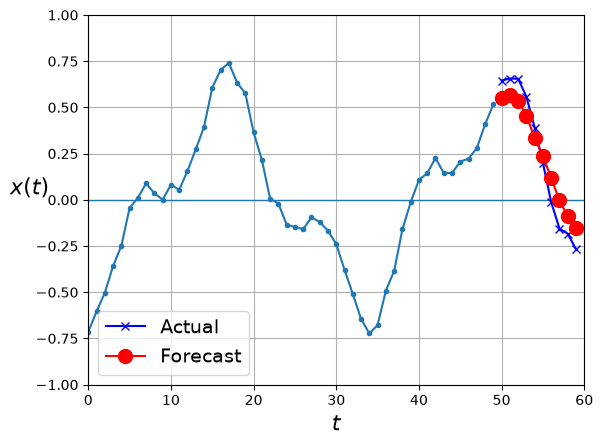

In [70]:
plot_multiple_forecasts(X_new, Y_new, Y_pred)
plt.show()

### 시퀀스-투-시퀀스 훈련

#### 시퀀스-투-시퀀스 심층 RNN (Many-to-many)

하지만 개선의 여지가 더 있다.

마지막 타임 스텝에서만 다음 10개의 값을 예측하도록 훈련하는 대신, 모든 타임 스텝에서 다음 10개의 값을 예측하는 훈련을 할 수 있다.

시퀀스-투-시퀀스 훈련이라고 한다. 

구체적으로 보자면 타임 스텝 0에서, "타임 스텝 1에서 10까지의 예측이 담긴 벡터"를 예측할 것이다.

그 다음 타임 스텝 1에서 이 모델은 타임 스텝 2에서 11까지 10개의 값을 예측할 것이다.

그 다음 타임 스텝 2에서 이 모델은 타임 스텝 3에서 12까지 10개의 값을 예측할 것이다.

위 방법과 가장 큰 차이는 y의 shape이다.

In [71]:
np.random.seed(42)

n_steps = 50
series = generate_time_series(10000, n_steps + 10)
X_train = series[:7000, :n_steps]
X_valid = series[7000:9000, :n_steps]
X_test = series[9000:, :n_steps]

아래 코드에서 `Y[:, i, :]`는 `Y`의 `i`번째 step의 값으로, 생성된 sequence의 `i+1`부터 `i+11`까지의 값을 가진다.

In [72]:
Y = np.empty((10000, n_steps, 10))
for i in range(n_steps):
    Y[:, i, :] = series[..., i+1:i+11, 0]
Y_train = Y[:7000]
Y_valid = Y[7000:9000]
Y_test = Y[9000:]

`Y`값을 step별로 하나씩 체크해 보자.

In [73]:
Y_train[0,0,:]

array([ 0.33874455,  0.18980233,  0.00611999, -0.19590542, -0.38614848,
       -0.54409838, -0.62904716, -0.66339582, -0.65724516, -0.51447874])

In [74]:
Y_train[0,1,:]

array([ 0.18980233,  0.00611999, -0.19590542, -0.38614848, -0.54409838,
       -0.62904716, -0.66339582, -0.65724516, -0.51447874, -0.42731112])

In [75]:
Y_train[0,2,:]

array([ 0.00611999, -0.19590542, -0.38614848, -0.54409838, -0.62904716,
       -0.66339582, -0.65724516, -0.51447874, -0.42731112, -0.26288131])

In [76]:
X_train[0,1:11]

array([[ 0.33874455],
       [ 0.18980233],
       [ 0.00611999],
       [-0.19590542],
       [-0.38614848],
       [-0.5440984 ],
       [-0.62904716],
       [-0.6633958 ],
       [-0.65724516],
       [-0.51447874]], dtype=float32)

In [77]:
X_train[3,22:32]

array([[ 0.34871522],
       [ 0.3379415 ],
       [ 0.36283925],
       [ 0.33348137],
       [ 0.31685767],
       [ 0.3044225 ],
       [ 0.17381966],
       [-0.07805993],
       [-0.25450805],
       [-0.47299817]], dtype=float32)

In [78]:
X_train.shape, Y_train.shape

((7000, 50, 1), (7000, 50, 10))

```Y_train.shape```이  ```(7000, 50, 10) = (number of sample, input time step, output time step)```인 것에 주목하라.  

* 직전의 방법에서는 ```Y_train.shape```이 ```(7000, 10)```

앞의 방법에서는 가장 마지막 스텝에서의 10개의 예측에 대해서만 훈련했다면, 

여기서는 모든 50번의 time step에서의 10개의 예측에 대해 훈련이 이루어진다.

이를 위해서는 모든 순환 층에 ```return_sequences=True```로 설정해야 한다.

#### TimeDistributed
    
아래 모형에서 모든 타임 스텝에서 출력을 Dense 층에 적용할 수 있도록 [```TimeDistributed```](https://keras.io/api/layers/recurrent_layers/time_distributed/)를 사용하였다.

```TimeDistributed``` 층은 층은 시계열의 각 타임 스텝을 서로 독립적인 샘플처럼 처리하여, 동일한 연산을 모든 타임 스텝에 반복 적용할 수 있도록 한다.

In [79]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.Input(shape=[None, 1]),
    keras.layers.SimpleRNN(20, return_sequences=True),
    keras.layers.SimpleRNN(20, return_sequences=True),
    keras.layers.TimeDistributed(keras.layers.Dense(10))
])

사실 이 예제에서 ```TimeDistributed(keras.layers.Dense())```는 기술적으로 ```Dense``` layer와 같은 역할을 한다.

```keras.layers.TimeDistributed(keras.layers.Dense(10))```를 ```keras.layers.Dense(10))```로 바꾸어도 같은 결과를 얻는다.

이는 Keras에서 입력 랭크가 3 이상이면 Dense layer가 입력의 마지막 축에 대해서만 계산을 적용하도록 구현이 되어 있기 때문이다. 

* 나머지 axis에 대해서는 자동으로 distributed 하여 계산하도록 구현되어 있음 

아래 간단한 예제를 통해 비교해 보자.

In [80]:
inp = np.array([[[1,1],
                 [0,1],
                 [1,0],
                 [-1,-2]],
                
                [[2,1],
                 [0,3],
                 [1,-1],
                 [1,-2]]])
inp.shape

(2, 4, 2)

In [81]:
dense_layer = keras.layers.Dense(3)

In [82]:
dense_layer(inp)

<tf.Tensor: shape=(2, 4, 3), dtype=float32, numpy=
array([[[ 1.4540573 , -0.7085316 ,  0.46622407],
        [ 1.0447645 ,  0.29556596, -0.5385598 ],
        [ 0.40929282, -1.0040976 ,  1.0047839 ],
        [-2.4988217 ,  0.41296566,  0.07233572]],

       [[ 1.8633502 , -1.7126292 ,  1.471008  ],
        [ 3.1342936 ,  0.8866979 , -1.6156794 ],
        [-0.6354717 , -1.2996635 ,  1.5433437 ],
        [-1.6802362 , -1.5952295 ,  2.0819035 ]]], dtype=float32)>

In [83]:
td_layer = keras.layers.TimeDistributed(dense_layer)
td_layer(inp)

<tf.Tensor: shape=(2, 4, 3), dtype=float32, numpy=
array([[[ 1.4540573 , -0.7085316 ,  0.46622407],
        [ 1.0447645 ,  0.29556596, -0.5385598 ],
        [ 0.40929282, -1.0040976 ,  1.0047839 ],
        [-2.4988217 ,  0.41296566,  0.07233572]],

       [[ 1.8633502 , -1.7126292 ,  1.471008  ],
        [ 3.1342936 ,  0.8866979 , -1.6156794 ],
        [-0.6354717 , -1.2996635 ,  1.5433437 ],
        [-1.6802362 , -1.5952295 ,  2.0819035 ]]], dtype=float32)>

하지만 `MaxPool2D`와 같은 layer는 `(batch, width, height, channels)`의 4차원까지의 데이터만 다룰 수 있게 되어 있어, 만약 여기에 시간 축이 추가된 데이터를 사용한다면 `TimeDistributed` 층을 반드시 이용해야 한다.

#### Model summary

아래 ```model.summary()``` 마지막 output shape이 ```(None, None, 10)```의 3차원임을 주목하라.

실제로는, ```(batch size, number of time step, 10)```을 얻는다.

이것은 ```Y_train.shape```인  ```(7000, 50, 10)```과 같다.

In [84]:
model.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_22 (SimpleRNN)       │ (None, None, 20)       │           440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_23 (SimpleRNN)       │ (None, None, 20)       │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, None, 10)       │           210 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,470 (5.74 KB)

 Trainable params: 1,470 (5.74 KB)

 Non-trainable params: 0 (0.00 B)

아래와 같은 RNN을 설계하는 방안도 생각해 볼 수 있다.

단지 마지막 layer가 RNN이므로 마지막 결과의 output이 순환적으로 학습에 다시 이용된다는 차이점이 있다.

In [85]:
model2 = keras.models.Sequential([
    keras.Input(shape=[None, 1]),
    keras.layers.SimpleRNN(20, return_sequences=True),
    keras.layers.SimpleRNN(20, return_sequences=True),
    keras.layers.SimpleRNN(10, return_sequences=True),
])
model2.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_24 (SimpleRNN)       │ (None, None, 20)       │           440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_25 (SimpleRNN)       │ (None, None, 20)       │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_26 (SimpleRNN)       │ (None, None, 10)       │           310 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,570 (6.13 KB)

 Trainable params: 1,570 (6.13 KB)

 Non-trainable params: 0 (0.00 B)

대략적으로 어떤 식으로 계산되는지 살펴보자. 

Training set 중의 하나의 시계열만 뽑아, input으로 넣어보자.

In [86]:
first_output = model.get_layer(index=0)(X_train[:1, :]) # 첫 번째 times series
first_output.shape

TensorShape([1, 50, 20])

In [87]:
second_output = model.layers[1](first_output)

```TimeDistributed``` 층으로 입력되는 데이터의 shape은 (배치크기, 타입스텝의 수, ...)으로 이루어져 있다.

In [88]:
# (batch size, time step, ...)
second_output.shape

TensorShape([1, 50, 20])

TimeDistributed 층에서는 각 time step 별 출력값들을 개별 데이터로 인식하여 계산에 사용한다. 

즉, 이 예제 구문에서는 1개의 $50 \times 20$ 데이터라기보다는 50개의 데이터 (그런데 각 데이터의 크기는 20)를 병렬적으로 입력으로 받는 것처럼 간주한다.

In [89]:
third_output = model.layers[2](second_output)
third_output.shape

TensorShape([1, 50, 10])

마지막 output의 shape은 ```[1,50,10]```이다.  
즉, 50개의 각 $x_t$에 대해 총 10개 씩의 output 즉, $x_{t+1}, \cdots, x_{t+10}$을 계산하였고, 이 값을 실제 관찰된 시계열 값들과 비교하여 훈련에 사용한다.

In [90]:
# model2도 마찬가지
model2.layers[2](second_output).shape

TensorShape([1, 50, 10])

훈련하는 동안에는 모든 출력이 필요하지만, 예측과 평가에는 마지막 타임 스텝의 출력만이 이용된다.  

아래 코드에서는 훈련과 평가에 사용하는 MSE들을 서로 조금 다르게 설정하였다.

훈련에는 모든 time step에서 MSE를 측정하여 이를 줄이도록 모형 parameter들을 적합하겠지만,

```metrics```으로서 평가에 사용하는 mse 함수는 마지막 custom function으로 마지막 step에서의 예측값 10개를 이용하여 계산한다.

User-defined metric 함수는 ```metric_fn(y_true, y_pred)```의 형태로 작성한다.

In [91]:
# 평가에 사용하는 user-defined mse, 마지막 예측의 정확도만 이용

def last_time_step_mse(Y_true, Y_pred):
    return keras.metrics.MSE(Y_true[:, -1, :], Y_pred[:, -1, :])

In [92]:
model.compile(loss="mse",   # 훈련에 필요한 mse
              optimizer=keras.optimizers.Adam(learning_rate=0.01), 
              metrics=[last_time_step_mse])  # 평가에 필요한 mse

history = model.fit(X_train, Y_train, epochs=20,
                    validation_data=(X_valid, Y_valid), verbose=2)

Epoch 1/20


219/219 - 8s - 39ms/step - last_time_step_mse: 0.0395 - loss: 0.0507 - val_last_time_step_mse: 0.0241 - val_loss: 0.0365


Epoch 2/20


219/219 - 3s - 14ms/step - last_time_step_mse: 0.0213 - loss: 0.0340 - val_last_time_step_mse: 0.0158 - val_loss: 0.0291


Epoch 3/20


...

219/219 - 3s - 14ms/step - last_time_step_mse: 0.0065 - loss: 0.0183 - val_last_time_step_mse: 0.0064 - val_loss: 0.0173


Epoch 19/20


219/219 - 3s - 13ms/step - last_time_step_mse: 0.0064 - loss: 0.0182 - val_last_time_step_mse: 0.0060 - val_loss: 0.0171


Epoch 20/20


219/219 - 5s - 24ms/step - last_time_step_mse: 0.0064 - loss: 0.0182 - val_last_time_step_mse: 0.0053 - val_loss: 0.0169


시계열 하나를 추가로 생성하여, 예측과 실제를 비교하는 그래프를 그려 보자.

In [93]:
np.random.seed(43)

series = generate_time_series(1, 50 + 10)
X_new, Y_new = series[:, :50, :], series[:, 50:, :]

X_new.flatten(), Y_new.flatten()

(array([-0.71430594, -0.60402304, -0.50313395, -0.35858592, -0.24881063,
        -0.04383381,  0.01058156,  0.08940701,  0.03474095,  0.00100053,
         0.08181838,  0.05386399,  0.15612572,  0.2726096 ,  0.39456058,
         0.60695225,  0.7012151 ,  0.7410105 ,  0.6343575 ,  0.575656  ,
         0.36496112,  0.21561034,  0.00555652, -0.02026231, -0.13460334,
        -0.14756192, -0.15892327, -0.09476995, -0.12051219, -0.16748159,
        -0.23957133, -0.37922844, -0.5098355 , -0.6450499 , -0.72317773,
        -0.6771738 , -0.4908803 , -0.38508183, -0.16000108, -0.01318712,
         0.10783868,  0.14367718,  0.22596198,  0.14425407,  0.14529224,
         0.2065604 ,  0.22278383,  0.2794281 ,  0.4081502 ,  0.51637864],
       dtype=float32),
 array([ 0.64557177,  0.6562027 ,  0.65506256,  0.5576619 ,  0.39075595,
         0.19883814, -0.0130802 , -0.15594868, -0.18422735, -0.2669426 ],
       dtype=float32))

In [94]:
Y_pred = model.predict(X_new)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 671ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 698ms/step


이렇게 얻어진 ```Y_pred```은 모든 time step에서 직후 10개에 대한 예측들을 담고 있다.

In [95]:
Y_pred.shape

(1, 50, 10)

첫 번째 time step 이후의 10개에 대한 예측, 즉, $x_2, x_3, \cdots, x_{11}$에 대한 예측

In [96]:
Y_pred[:, 0]

array([[-5.5061680e-01, -4.5736432e-01, -3.3067316e-01, -1.6818884e-01,
         3.0723726e-04,  1.4479351e-01,  2.5070462e-01,  3.1849402e-01,
         3.4520394e-01,  3.4217116e-01]], dtype=float32)

In [97]:
Y_pred[:, 0, :]

array([[-5.5061680e-01, -4.5736432e-01, -3.3067316e-01, -1.6818884e-01,
         3.0723726e-04,  1.4479351e-01,  2.5070462e-01,  3.1849402e-01,
         3.4520394e-01,  3.4217116e-01]], dtype=float32)

두 번째 time step 이후의 예측, 즉, $x_3, x_4, \cdots, x_{12}$에 대한 예측

In [98]:
# 두 번째 time step 이후의 예측
Y_pred[:, 1]

array([[-4.7712758e-01, -3.2365581e-01, -1.7120931e-01, -5.7175756e-05,
         1.3235299e-01,  2.2578387e-01,  2.7832347e-01,  3.0232450e-01,
         3.1270486e-01,  3.3176920e-01]], dtype=float32)

마지막 10개에 대한 예측

In [99]:
Y_pred[:, 49]

array([[ 0.63065803,  0.6814235 ,  0.6465812 ,  0.54252386,  0.38903838,
         0.20962258,  0.03454032, -0.11626065, -0.21986315, -0.2763379 ]],
      dtype=float32)

In [100]:
Y_pred[:, -1]

array([[ 0.63065803,  0.6814235 ,  0.6465812 ,  0.54252386,  0.38903838,
         0.20962258,  0.03454032, -0.11626065, -0.21986315, -0.2763379 ]],
      dtype=float32)

실제 실현된 마지막 10개

In [101]:
Y_new

array([[[ 0.64557177],
        [ 0.6562027 ],
        [ 0.65506256],
        [ 0.5576619 ],
        [ 0.39075595],
        [ 0.19883814],
        [-0.0130802 ],
        [-0.15594868],
        [-0.18422735],
        [-0.2669426 ]]], dtype=float32)

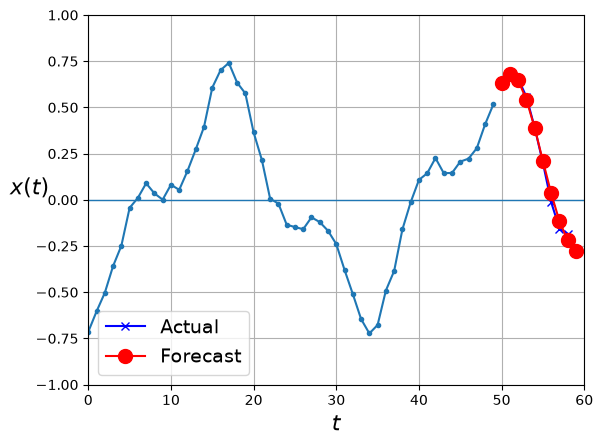

In [102]:
plot_multiple_forecasts(X_new, Y_new, Y_pred[:, -1][..., np.newaxis])
plt.show()

`Timedistributed`를 사용하지 않은 아래의 모델로도 실험해 보자.

```
model3 = keras.models.Sequential([
    keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.SimpleRNN(20, return_sequences=True),
    keras.layers.Dense(10)
])

model3.compile(loss="mse",   
              optimizer=keras.optimizers.Adam(learning_rate=0.01), 
              metrics=[last_time_step_mse])  

history = model3.fit(X_train, Y_train, epochs=20,
                    validation_data=(X_valid, Y_valid))
```

## LSTM (Long short-term memory)

RNN을 거치며 일부 정보는 매 훈련 스텝 후 사라진다. 어느 정도 시간이 지나면 RNN의 상태는 사실상 첫 번째의 입력의 흔적을 가지고 있지 않다. 

이에 장기 메모리를 가진 여러 셀이 연구되었다. 

[`LSTM`](https://keras.io/api/layers/recurrent_layers/lstm/)은 장기 메모리를 가진 뉴럴 네트워크로 위에서 살펴본 간단한 RNN 보다 많은 경우 좋은 성능을 보인다. 

* LSTM은 긴 시퀀스에서 발생하는 장기 의존성을 효과적으로 학습할 수 있다.

* LSTM은 게이트 메커니즘을 사용하여 오래 기억할 정보와 삭제할 정보를 결정한다.

[`GRU`](https://keras.io/api/layers/recurrent_layers/gru/) layer 또한 많이 이용된다.

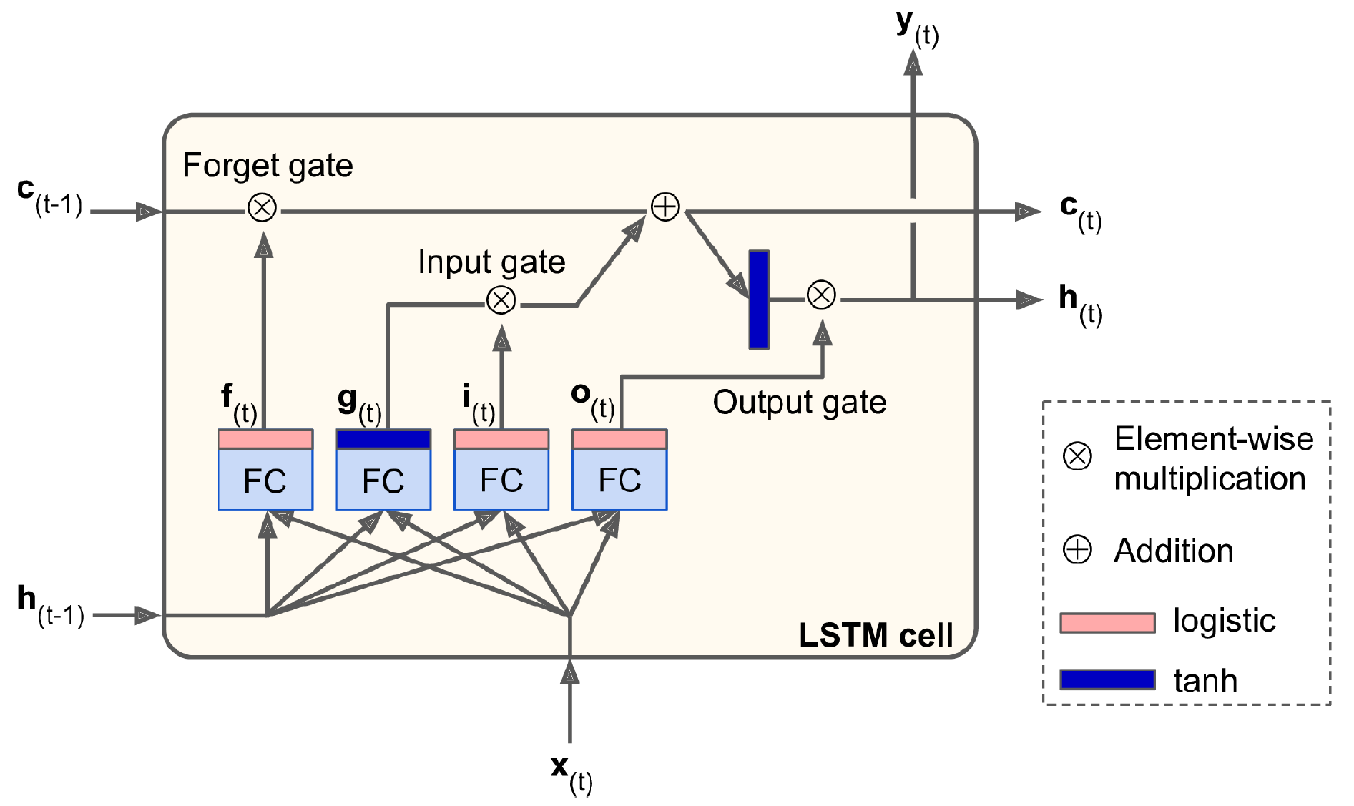

LSTM을 설명한 위 그림을 간단히 요약하자면 다음과 같다.

* **h (hidden state, 출력용 state)**

  * LSTM에서 `h`는 cell state `c`를 기반으로 계산되는 현재 시점의 요약 정보.
    
  * 출력 관점에서, 앞서 SimpleRNN 설명에서 `y`와 유사한 역할을 한다.
    
    * 즉, `return_sequences=True`로 설정하면 `[h_1, h_2, ..., h_T]`를 출력받을 수 있다. <br><br>
  
  * 또한 입력 `x`와 함께 layer의 각종 파라미터 `W`와의 연산에 활용된다.
    
  * SimpleRNN에서는 $\tanh$ 활성화 함수 때문에 정보가 빠르게 희석될 수 있는 반면,
    
      * LSTM에서는 장기 메모리 `c`를 기반으로 `h`가 계산되어 이 부작용을 줄임. <br><br>

* **c (장기 메모리, cell state)**

  * 장기 기억이 필요한 정보를 저장하고, 선형 구조로 되어 있어, 오랜 시간에 걸쳐 선형적으로 정보 누적 가능.
    
  * 어떤 정보를 기억하고 어떤 정보를 잊을지는 forget gate와 input gate에 의해 결정된다.

### LSTM의 핵심: 게이트(Gates)

LSTM은 다음과 같은 게이트 메커니즘을 통해 정보를 선택적으로 기억/삭제한다.

1. **Forget gate `f`**:

   * 이전 hidden state `h_{t-1}`와 현재 입력 `x_t`를 바탕으로 이전의 cell state `c_{t-1}` 중 어떤 정보를 잊을지 결정한다.
     
   * 아래 수식에서 $\sigma$는 sigmoid 함수로, 0과 1사이의 값을 가지며, forget gate는 강도를 조절하는 스위치 역할을 할 예정
$$
f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)
$$

2. **Input gate `i`**:

   * 현재 입력 `x_t`와 이전 hidden state `h_{t-1}`를 바탕으로, 어떤 정보를 새로 저장할지 결정
     
   * 마찬가지로 input gate 또한 강도를 조절하는 스위치 역할을 할 예정
$$
i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)
$$

3. **Candidate `g`** 혹은 $\tilde{c}$:

   * 현재 입력 `x_t`와 이전 hidden state `h_{t-1}`를 바탕으로 생성된, 새롭게 기억될 만한 정보의 후보이다.
  
   * `tanh` 활성화를 통해 계산되며, input gate와 함께 실제 cell state 업데이트에 사용된다.

   * `tanh`는 -1과 1사이의 값을 가지며, cell state가 폭주하거나 불안정해지는 것을 방지하고, 장기 메모리의 안정적 업데이트 가능
   
   * 구조적으로는 SimpleRNN의 뉴런과 유사한 역할을 한다.
$$
\tilde{c}_t = \tanh(W_c \cdot [h_{t-1}, x_t] + b_c)
$$

4. **Cell state 업데이트**:

   * 이전 cell state `c_{t-1}`는 forget gate `f_t`와 요소별 곱으로 일부 정보는 유지되고 일부는 삭제된다.
   
   * 동시에, 새로 생성된 후보 기억 $\tilde{c}_t$는 input gate `i_t`와 요소별 곱해져 cell state에 추가된다.
   
   * 두 항의 합으로 새로운 cell state `c_t`가 형성된다.
$$
c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t
$$

5. **Output gate `o`**:

   * 현재 입력 `x_t`, 단기 메모리 `h_{t-1}`를 바탕으로 어떤 정보를 출력할지 결정한다.
   
   * Output gate의 출력은 cell state의 활성화된 형태와 곱해져 최종 hidden state `h_t`를 생성한다
     
   * 이 `h_t`는 다음 시점으로 전달되며, 일반적인 LSTM 구조에서는 곧 현 시점의 출력(`y_t`)으로도 간주된다. (즉, 대부분의 경우 `y_t = h_t`)
  
$$
o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)
$$

6. **Hidden state (출력)**

- 출력되는 hidden state `h_t`는 output gate의 출력과 장기 메모리 `c_t`의 활성화 결과를 요소 곱하여 출력

$$
h_t = o_t \odot \tanh(c_t)
$$


위 과정을 한 줄로 표현하면 다음과 같다.

$$ c_t, h_t = \text{LSTMCell}(x_t, c_{t-1}, h_{t-1}) = \Big( f_t \odot c_{t-1} + i_t \odot \tilde{c}_t,\; o_t \odot \tanh({c}_t) \Big) 
$$

여기서,

$$
f_t = \sigma(z_f), \quad
i_t = \sigma(z_i), \quad
\tilde{c}_t = \tanh(z_c), \quad
o_t = \sigma(z_o), \quad
[z_f, z_i, z_c, z_o] = W \cdot [h_{t-1}, x_t] + b, \quad
W = 
\begin{bmatrix}
W_f \\
W_i \\
W_c \\
W_o
\end{bmatrix}
$$


아래 예제에서 위에서 수행한 시계열 예측 문제를 다시 수행해보자.

먼저 LSTM을 두 개 이용하여 심층 순환 신경망을 생성하였다. 

따라서, 이 부분의 $t$시점 연산은 다음과 같이 요약될 수 있다.

$$ \mathbf{h}^{(2)}_t = \text{LSTM}^{(2)}\left(\text{LSTM}^{(1)}(\mathbf{x}_t, \mathbf{h}^{(1)}_{t-1}, \mathbf{c}^{(1)}_{t-1}), \mathbf{h}^{(2)}_{t-1}, \mathbf{c}^{(2)}_{t-1} \right), \quad
\mathbf{y}_t = \mathbf{W}_y \cdot \mathbf{h}^{(2)}_t + \mathbf{b}_y 
$$

In [103]:
model = keras.models.Sequential([
    keras.Input(shape=[None, 1]),
    keras.layers.LSTM(20, return_sequences = True),
    keras.layers.LSTM(20, return_sequences = True),
    keras.layers.TimeDistributed(keras.layers.Dense(10)) # TimeDistributed 생략 가능
])

In [104]:
model.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, None, 20)       │         1,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, None, 20)       │         3,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, None, 10)       │           210 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,250 (20.51 KB)

 Trainable params: 5,250 (20.51 KB)

 Non-trainable params: 0 (0.00 B)

### 모델의 파라미터 수 계산

#### LSTM 첫번째 층

`keras.layers.LSTM(20, return_sequences = True, input_shape = [None, 1])`

* LSTM의 파라미터 수 공식:

  $$
  \text{params} = 4 \cdot \text{units} \cdot (\text{units} + \text{input\_dim} + 1)
  $$

  (4는 gate 수: input, forget, cell, output)

* 계산:

  $$
  = 4 \cdot 20 \cdot (20 + 1 + 1) = 4 \cdot 20 \cdot 22 = 1760 \text{개}
  $$

#### LSTM 두번째 층

`keras.layers.LSTM(20, return_sequences = True)`

* 두 번째 층: 입력 dim = 20 → 파라미터

  $$
  4 \cdot 20 \cdot (20 + 20 + 1) = 4 \cdot 20 \cdot 41 = 3280 \text{개}
  $$


In [105]:
model.compile(loss="mse",   # 훈련에 필요한 mse
              optimizer=keras.optimizers.Adam(learning_rate=0.01), 
              metrics=[last_time_step_mse])  # 평가에 필요한 mse

history = model.fit(X_train, Y_train, epochs=20,
                    validation_data=(X_valid, Y_valid), verbose=2)

Epoch 1/20


219/219 - 13s - 58ms/step - last_time_step_mse: 0.0311 - loss: 0.0452 - val_last_time_step_mse: 0.0125 - val_loss: 0.0287


Epoch 2/20


219/219 - 5s - 25ms/step - last_time_step_mse: 0.0118 - loss: 0.0267 - val_last_time_step_mse: 0.0090 - val_loss: 0.0239


Epoch 3/20


...

219/219 - 10s - 46ms/step - last_time_step_mse: 0.0029 - loss: 0.0132 - val_last_time_step_mse: 0.0027 - val_loss: 0.0128


Epoch 19/20


219/219 - 6s - 26ms/step - last_time_step_mse: 0.0028 - loss: 0.0131 - val_last_time_step_mse: 0.0027 - val_loss: 0.0128


Epoch 20/20


219/219 - 3s - 12ms/step - last_time_step_mse: 0.0028 - loss: 0.0131 - val_last_time_step_mse: 0.0027 - val_loss: 0.0128


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step


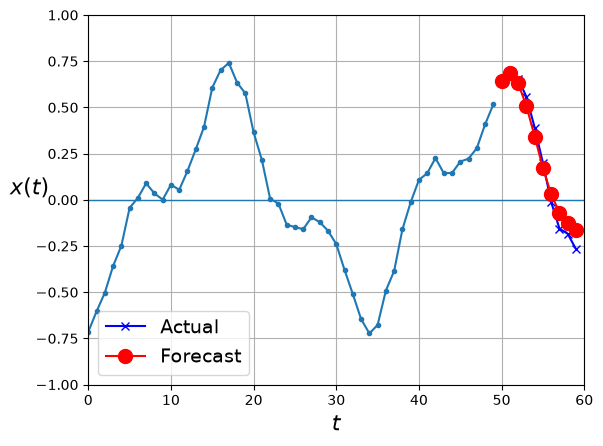

In [106]:
Y_pred = model.predict(X_new)
plot_multiple_forecasts(X_new, Y_new, Y_pred[:, -1][..., np.newaxis])
plt.show()
